# Multivariate Regression Covid

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [3]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [4]:
df['country'].unique()

array(['Chile', 'Colombia', 'Italy', 'Mexico', 'US'], dtype=object)

# Wrangle

In [5]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [6]:
df.rename(columns={'Mean_distance_avg_14day_movavg':'14d_avg_dist',
                    'StringencyIndex_Average':'StringencyIndex'}, inplace = True)

In [7]:
df['cases_t_1'] = df.groupby('country')['cases'].shift(-1)

In [8]:
# ------------------------------------------------------------------
# 1.  Sort once so groupby‑shift/rolling are correct
# ------------------------------------------------------------------
df = df.sort_values(['country', 'date']).reset_index(drop=True)

# ------------------------------------------------------------------
# 2.  Create lag‑1 and lag‑2 features for the weekly target
#     (replace 'cases_t_1' with your true target column name
#      if it differs) 
# ------------------------------------------------------------------
for lag in [1, 2]:
    df[f'cases_lag_{lag}'] = (
        df.groupby('country')['cases_t_1']
          .shift(lag)
    )

# ------------------------------------------------------------------
# 3.  Two‑period rolling mean of the *previous* weeks
#     (window=2, min_periods=1 lets the first available lag
#      propagate instead of NaN)
# ------------------------------------------------------------------
df['cases_roll_mean_2'] = (
    df.groupby('country')['cases_t_1']
      .shift(1)                      # exclude the current week
      .rolling(window=2, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)   # drop group index after rolling
)

# Optional: fill remaining NaNs after the very first week for each country
df = df.dropna(subset=['cases_t_1'])
df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer

C:\Users\danie\AppData\Local\Temp\ipykernel_15756\2134973485.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer


In [9]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())
df['month'] = df['date'].dt.month



In [10]:
df_og = df.copy()

# Regression Framework

In [11]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## OLS

In [12]:
from sklearn.linear_model import LinearRegression
df = df_og.copy()

    country          rmse        r2
0     Chile  6.014858e+04  0.998800
1  Colombia  1.148425e+05  0.368338
2     Italy  3.180440e+05  0.998845
3    Mexico  1.869378e+05  0.971524
4        US  1.650734e+06  0.993119
country             Chile      Colombia         Italy         Mexico  \
date                                                                   
2020-03-23   24908.999999   8087.999985  8.067540e+05   10918.000009   
2020-03-30   62825.581916  43388.383159  1.282301e+06   43317.861222   
2020-04-06   68831.114260  51816.497774  1.257176e+06   62319.027390   
2020-04-13   73264.110707  38203.904018  1.307041e+06   39779.864169   
2020-04-20  116299.123665  18090.223641  1.442862e+06  103821.310220   

country               US  
date                      
2020-03-23  1.815950e+06  
2020-03-30  5.200570e+06  
2020-04-06  4.609075e+06  
2020-04-13  6.134927e+06  
2020-04-20  7.805161e+06  


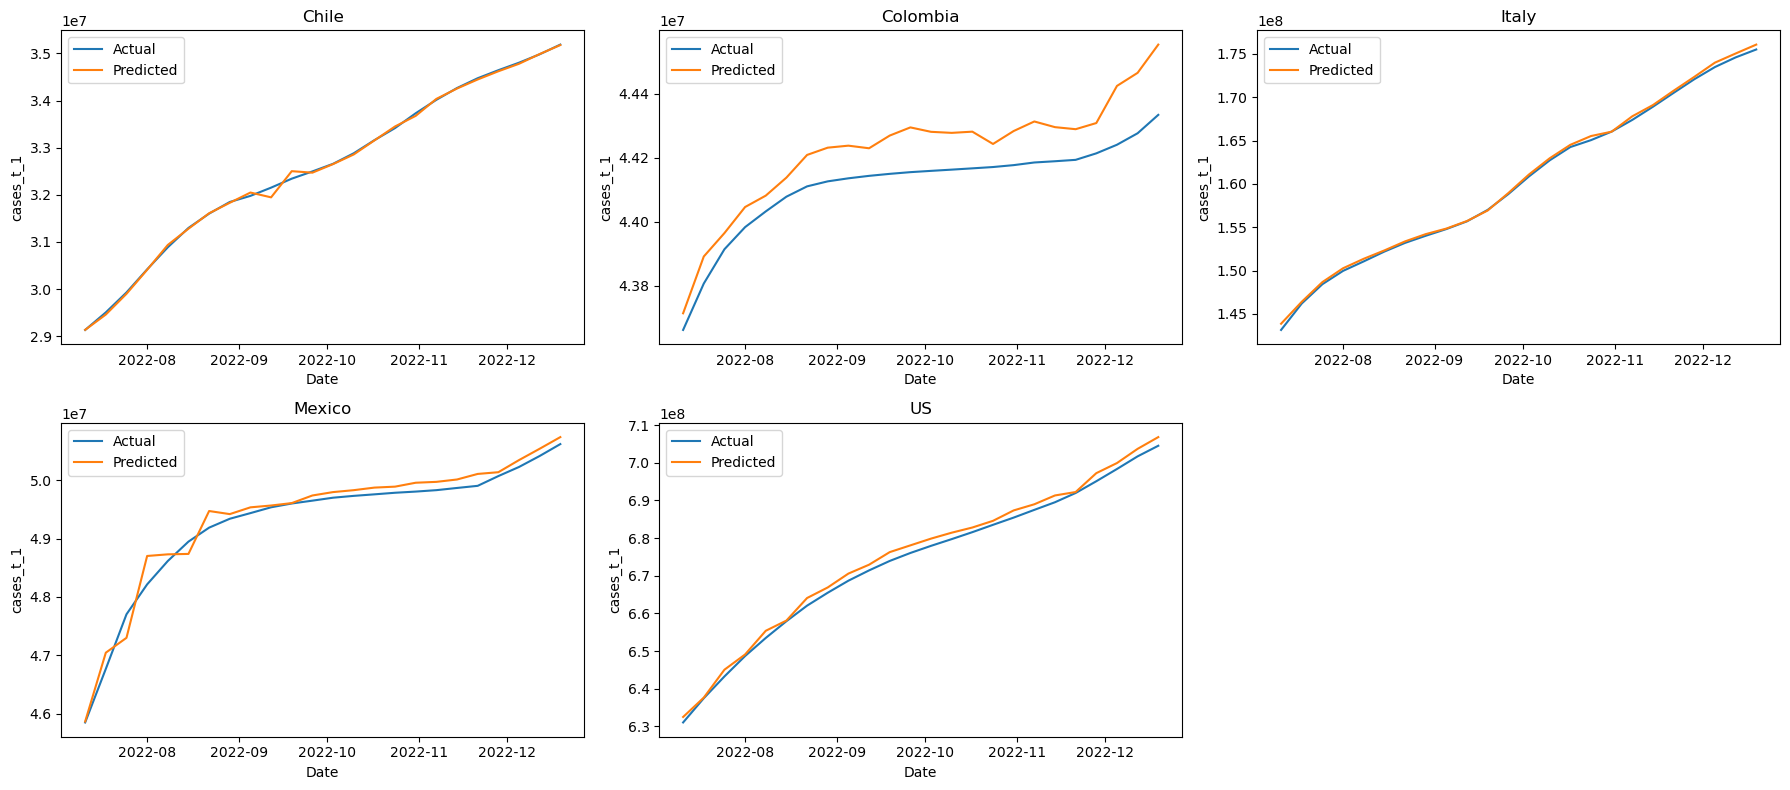

In [13]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for plotting
fit_records   = []   # date‑wise fitted values —> will pivot later

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date'])
    X = X.select_dtypes(include='number')

    # ---- 1.3  Time‑series split: last fold is hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Fit Linear Regression
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred_test  = linreg.predict(X_test)
    y_pred_train = linreg.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values for *all* rows (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table (unchanged)
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  ← NEW
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)          # long
      .pivot(index='date', columns='country', values='fitted')  # wide
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot section (unchanged)
# -------------------------------------------------------------
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

In [14]:
fitted_df.to_csv('../results/OLS_covid.csv', index = True)

## Lasso

In [15]:
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LassoCV
df = df_og.copy()


    country           rmse        r2          alpha
0     Chile   77347.832077  0.998015    8128.394737
1  Colombia   33399.354109  0.946574   15742.949372
2     Italy  298846.905735  0.998981   39359.444263
3    Mexico  133158.434923  0.985552   13612.259602
4        US  776684.076718  0.998477  196705.554112
country             Chile      Colombia         Italy         Mexico  \
date                                                                   
2020-03-23   96736.084131  74453.285033  1.017485e+06   87449.173374   
2020-03-30  102898.855904  80888.310011  1.047329e+06   65196.996340   
2020-04-06  105348.198243  83907.861792  1.174165e+06   66898.465380   
2020-04-13  106141.313243  64948.387690  1.229292e+06   63857.648971   
2020-04-20  148116.055105  78999.779993  1.366733e+06  133747.320289   

country               US  
date                      
2020-03-23  1.998417e+06  
2020-03-30  3.860651e+06  
2020-04-06  4.817579e+06  
2020-04-13  6.156899e+06  
2020-04-20  7.558120e

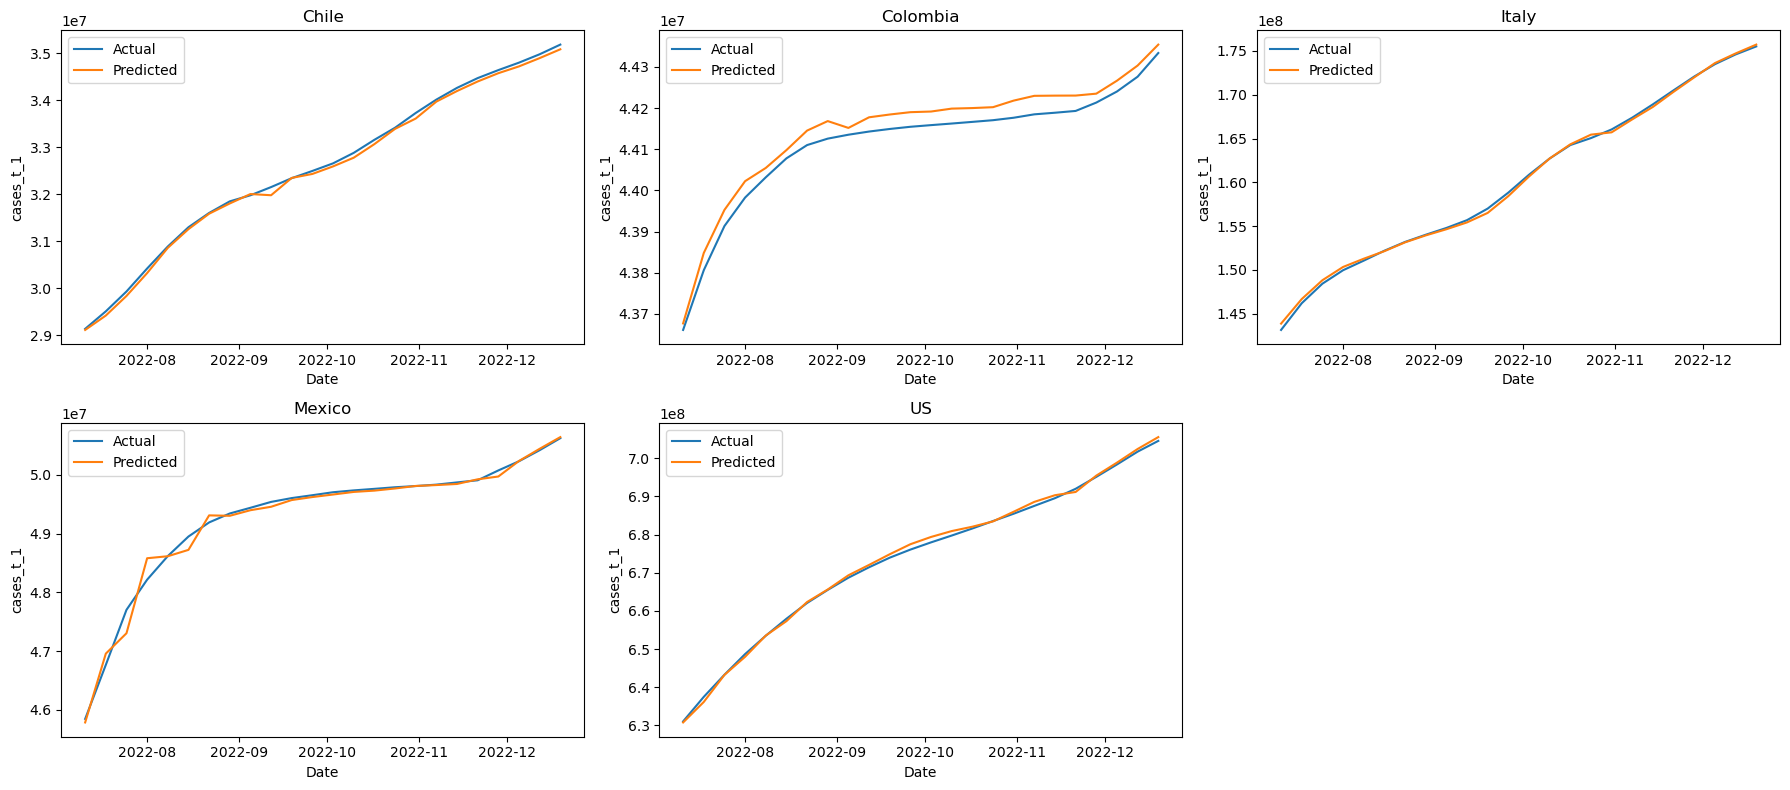

In [16]:



# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date']).select_dtypes(include='number')

    # ---- 1.3  Time‑series split: last fold is hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Build a pipeline: StandardScaler → LassoCV
    #           Use inner CV (time‑series) to choose alpha
    inner_cv = TimeSeriesSplit(n_splits=3)

    lasso_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("model",  LassoCV(cv=inner_cv, random_state=42, n_alphas=50, max_iter=5000))
        ]
    )

    lasso_pipe.fit(X_train, y_train)
    best_alpha = lasso_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = lasso_pipe.predict(X_test)
    y_pred_train = lasso_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [17]:
# store results
fitted_df.to_csv('../results/Lasso_covid.csv', index = True)

## Ridge

In [18]:
from sklearn.linear_model  import RidgeCV
df = df_og.copy()

    country          rmse        r2  alpha
0     Chile  5.366014e+04  0.999045  0.001
1  Colombia  1.302617e+05  0.187332  0.001
2     Italy  3.704467e+05  0.998434  0.001
3    Mexico  1.835332e+05  0.972552  0.001
4        US  1.691830e+06  0.992772  0.001
country             Chile      Colombia         Italy         Mexico  \
date                                                                   
2020-03-23   50171.508099  10627.695196  8.207010e+05   11268.164859   
2020-03-30   55161.908337  42202.600833  1.260597e+06   42698.389194   
2020-04-06   62285.530084  54716.577727  1.288598e+06   61705.070221   
2020-04-13   67353.360555  33694.555826  1.310969e+06   38878.120144   
2020-04-20  106049.549764  12351.491228  1.414195e+06  104044.136409   

country               US  
date                      
2020-03-23  2.186090e+06  
2020-03-30  4.554302e+06  
2020-04-06  4.625919e+06  
2020-04-13  6.185905e+06  
2020-04-20  7.660411e+06  


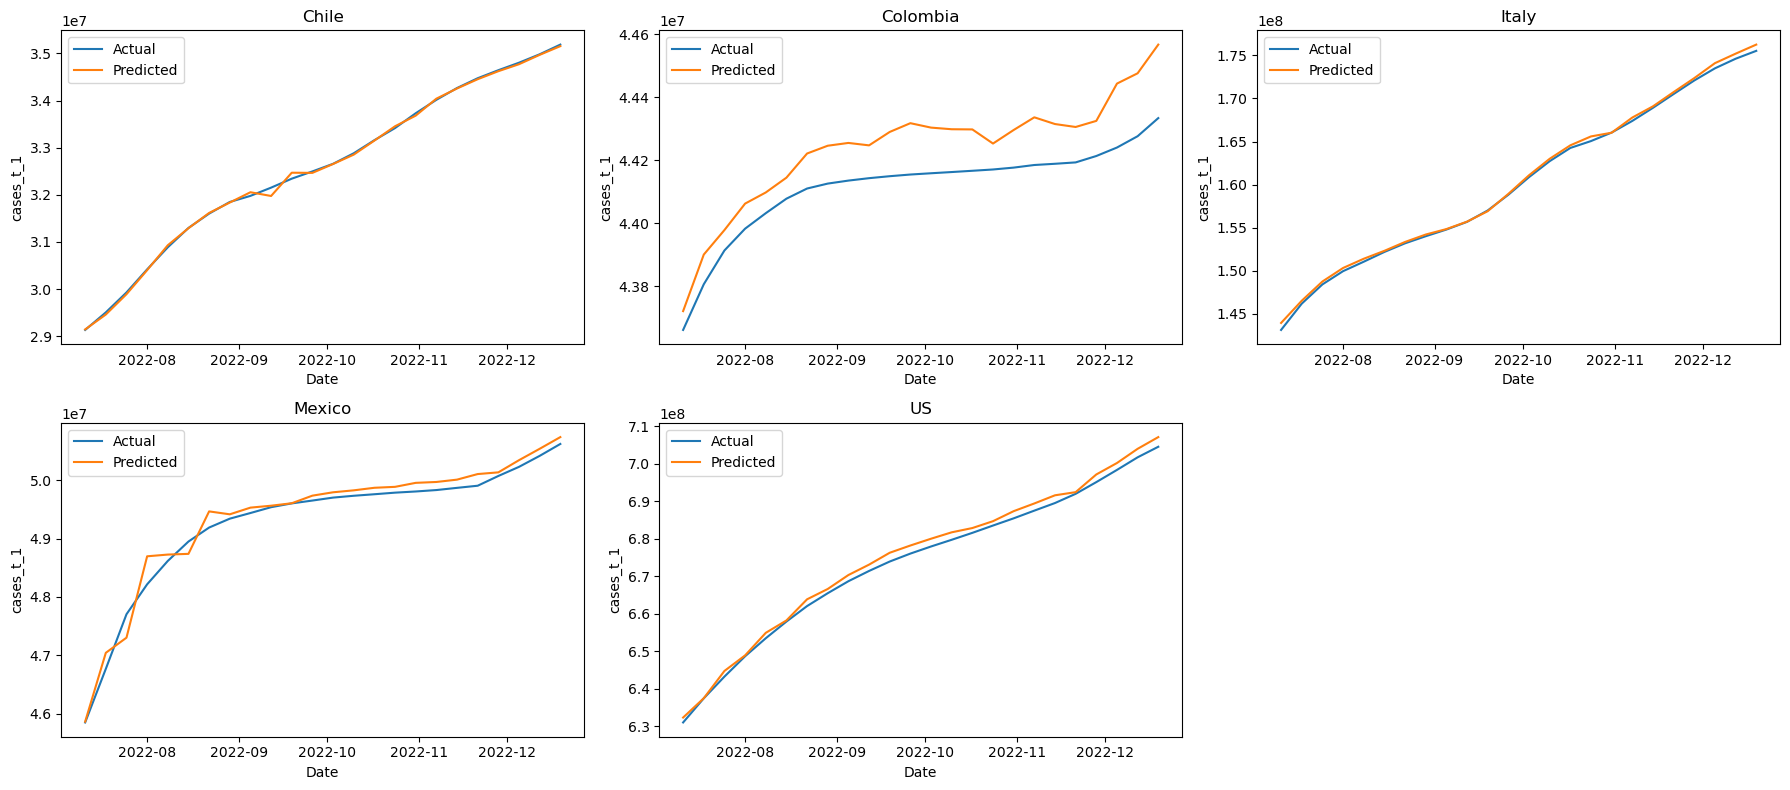

In [19]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])
         .select_dtypes(include='number'))

    # ---- 1.3  Time‑series split: last fold is true hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → RidgeCV
    inner_cv = TimeSeriesSplit(n_splits=3)
    ridge_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                               cv=inner_cv,
                               scoring='neg_root_mean_squared_error'))
        ]
    )

    ridge_pipe.fit(X_train, y_train)
    best_alpha = ridge_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = ridge_pipe.predict(X_test)
    y_pred_train = ridge_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [20]:
# save the fitted values
fitted_df.to_csv('../results/Ridge_covid.csv', index = True)

## Elastic Net

In [21]:
from sklearn.linear_model  import ElasticNetCV
df = df_og.copy()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 399107875185.9743, tolerance: 153903599305.61743
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 274735317467.25433, tolerance: 153903599305.61743
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 891080188133.1362, tolerance: 287144690359.5813
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\

    country          rmse        r2  alpha
0     Chile  5.514645e+04  0.998991  0.001
1  Colombia  1.977400e+05 -0.872702  0.001
2     Italy  3.009558e+05  0.998966  0.001
3    Mexico  1.697819e+05  0.976511  0.001
4        US  2.348918e+06  0.986067  0.001
country             Chile       Colombia         Italy         Mexico  \
date                                                                    
2020-03-23   37524.318772  136001.783727  1.402455e+06   29508.634095   
2020-03-30   44631.710978  -32421.183909  1.134755e+06   13291.361766   
2020-04-06   57331.746887   83428.026304  1.252894e+06   72037.204801   
2020-04-13   70520.078151  -43305.922303  1.191748e+06   39033.318288   
2020-04-20  100405.879093  -30054.175694  1.303442e+06  126796.864658   

country               US  
date                      
2020-03-23  6.303989e+06  
2020-03-30  1.447452e+06  
2020-04-06  3.410645e+06  
2020-04-13  6.271007e+06  
2020-04-20  7.644655e+06  


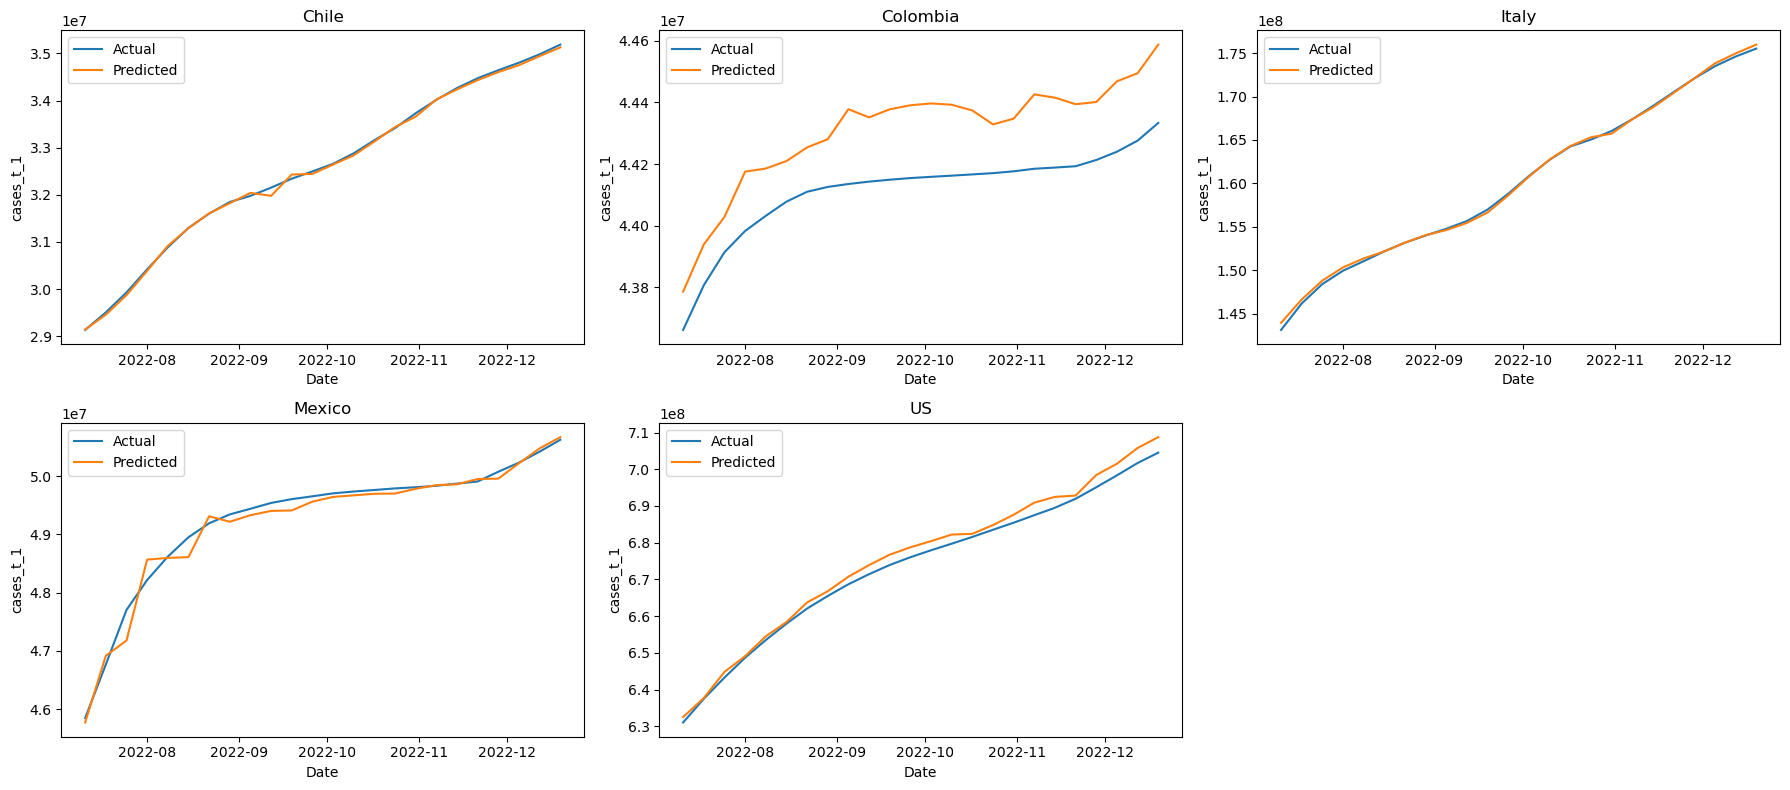

In [22]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Sort chronologically
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])
         .select_dtypes(include='number'))

    # ---- 1.3  Time‑series split: last fold is true hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → ElasticNetCV (l1_ratio = 0.5)
    inner_cv = TimeSeriesSplit(n_splits=3)
    enet_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model",  ElasticNetCV(
                          l1_ratio       = 0.5,                # 50‑50 mix
                          alphas         = np.logspace(-3, 3, 30),
                          cv             = inner_cv,
                          random_state   = 42,
                          max_iter       = 5000))
        ]
    )

    enet_pipe.fit(X_train, y_train)
    best_alpha = enet_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = enet_pipe.predict(X_test)
    y_pred_train = enet_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [23]:
# save fitted values
fitted_df.to_csv('../results/ElasticNet_covid.csv', index = True)

## Random Forest

In [24]:
from sklearn.model_selection import  GridSearchCV
from sklearn.ensemble      import RandomForestRegressor
df = df_og.copy()

    country          rmse         r2  \
0     Chile  5.746724e+06  -9.958385   
1  Colombia  9.851270e+05 -45.479761   
2     Italy  3.265714e+07 -11.172561   
3    Mexico  7.231555e+06 -41.613343   
4        US  8.362716e+07 -16.660272   

                                         best_params  
0  {'bootstrap': False, 'max_depth': None, 'max_f...  
1  {'bootstrap': False, 'max_depth': None, 'max_f...  
2  {'bootstrap': False, 'max_depth': 10, 'max_fea...  
3  {'bootstrap': False, 'max_depth': None, 'max_f...  
4  {'bootstrap': False, 'max_depth': None, 'max_f...  
country        Chile  Colombia      Italy    Mexico         US
date                                                          
2020-03-23   24909.0    8088.0   806754.0   10918.0  1815950.0
2020-03-30   43938.0   15594.0  1007392.0   24570.0  3363343.0
2020-04-06   65523.0   23021.0  1183431.0   45190.0  4792373.0
2020-04-13   90640.0   32445.0  1328505.0   81841.0  6212168.0
2020-04-20  128143.0   46219.0  1437446.0  135602.0

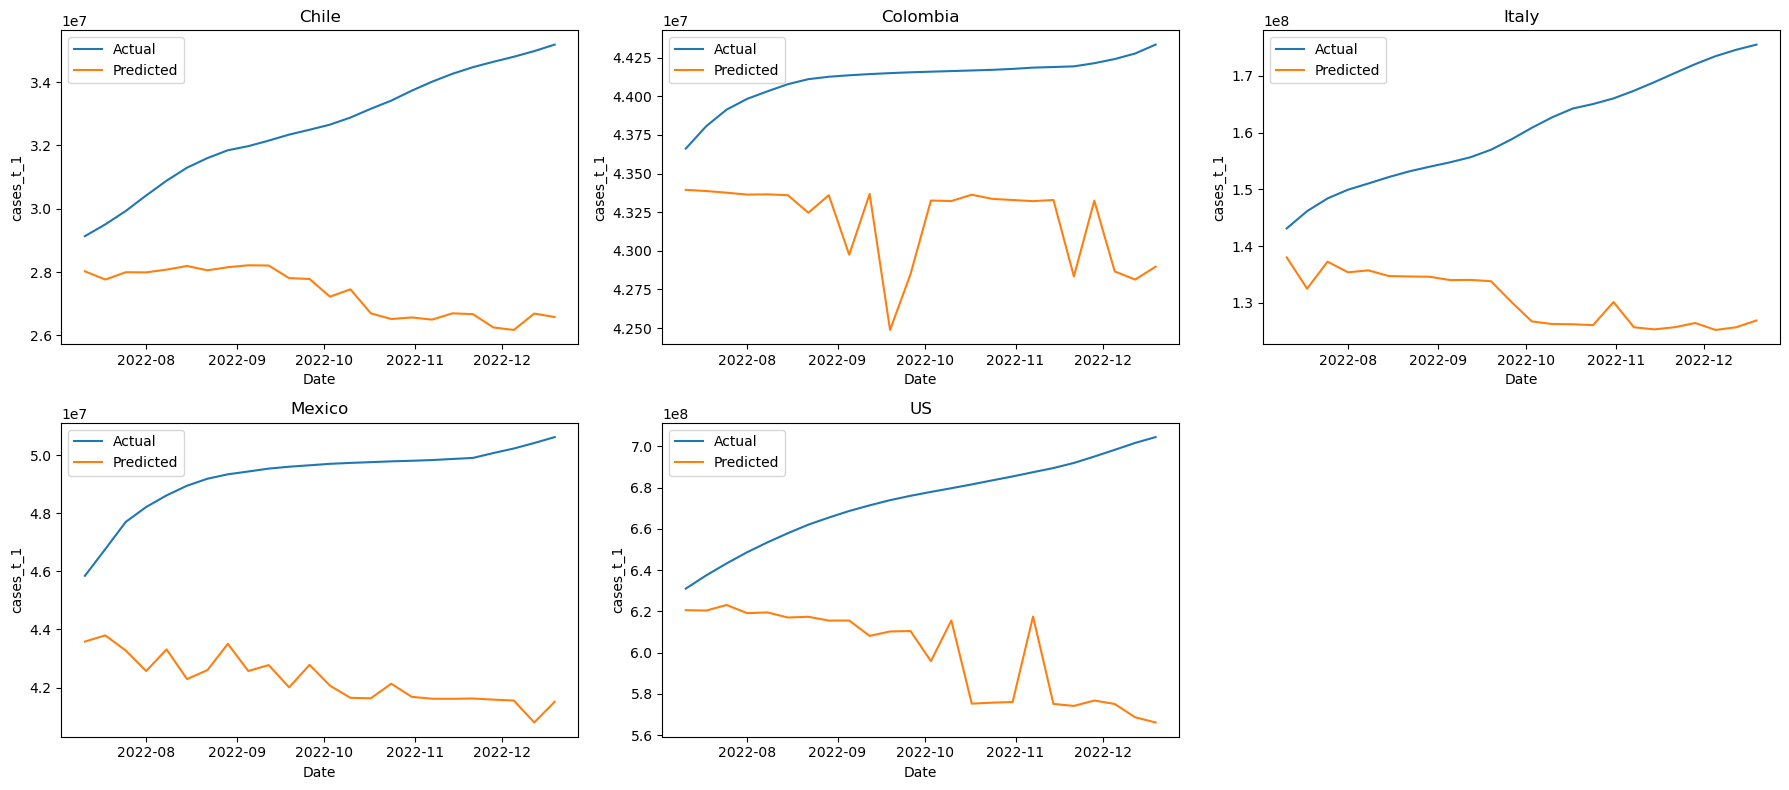

In [25]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (start coarse → tighten later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [400, 800, 1200],
    "max_depth":         [None, 10, 20],
    "max_features":      ["sqrt", 0.6, 0.8],
    "min_samples_leaf":  [1, 3, 5],
    "bootstrap":         [True, False]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Sort chronologically
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])   # drop target & date
         .select_dtypes(include='number'))      # numeric predictors only

    # ---- 2.3  Time‑series split: last fold is true hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Inner CV: grid‑search random forest on training portion
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_rf    = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [26]:
fitted_df.to_csv('../results/RF_covid.csv', index = True)

## Gradient Boosting

In [27]:
from sklearn.ensemble      import GradientBoostingRegressor
df = df_og.copy()

    country          rmse         r2  \
0     Chile  4.818455e+06  -6.704092   
1  Colombia  8.068451e+05 -30.178829   
2     Italy  2.839019e+07  -8.199462   
3    Mexico  5.361118e+06 -22.420326   
4        US  5.916511e+07  -7.839628   

                                         best_params  
0  {'learning_rate': 0.03, 'max_depth': 2, 'max_f...  
1  {'learning_rate': 0.1, 'max_depth': 2, 'max_fe...  
2  {'learning_rate': 0.03, 'max_depth': 2, 'max_f...  
3  {'learning_rate': 0.05, 'max_depth': 2, 'max_f...  
4  {'learning_rate': 0.03, 'max_depth': 2, 'max_f...  
country             Chile      Colombia         Italy         Mexico  \
date                                                                   
2020-03-23   25142.770019   8634.455143  8.340135e+05   15687.160808   
2020-03-30   45480.658856  14833.286228  1.011384e+06   25540.825059   
2020-04-06   66829.642890  22487.488479  1.186157e+06   43824.146149   
2020-04-13   91613.939228  32800.389112  1.331786e+06   74274.589158 

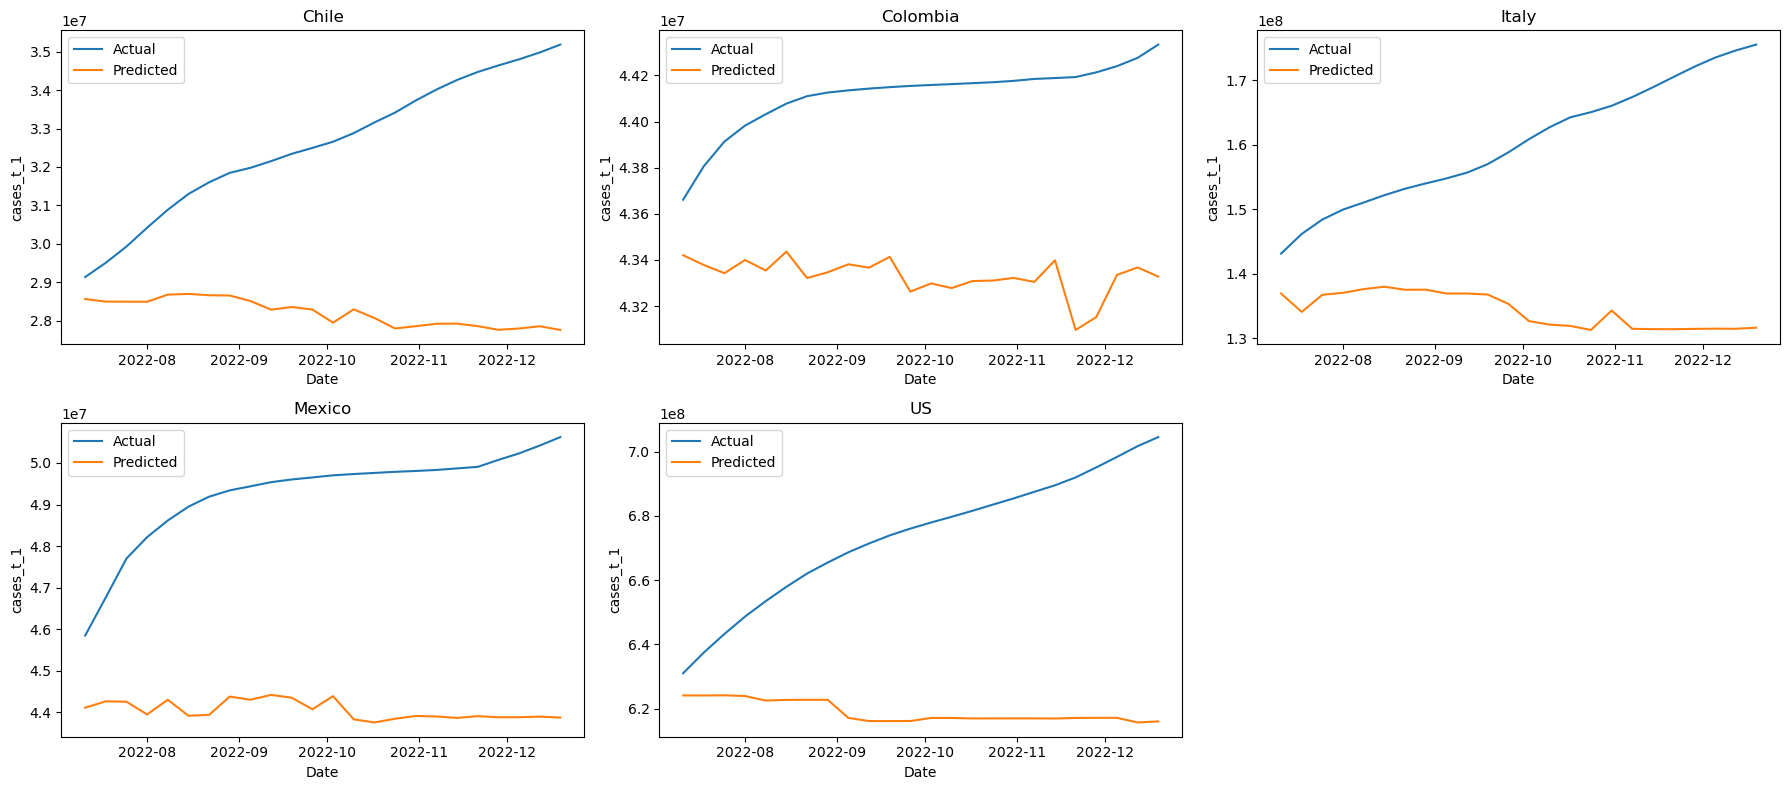

In [28]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for hold‑out plots
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (coarse → refine later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [200, 400, 800],
    "learning_rate":     [0.03, 0.05, 0.1],
    "max_depth":         [2, 3, 4],        # depth of individual trees
    "subsample":         [0.7, 0.9, 1.0],
    "min_samples_leaf":  [1, 3, 5],
    "max_features":      ["sqrt", 0.6, None]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])
         .select_dtypes(include='number'))

    # ---- 2.3  Time‑series split: last fold is hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Grid‑search GBM on training portion
    inner_cv  = TimeSeriesSplit(n_splits=3)
    gb_base   = GradientBoostingRegressor(random_state=42)

    grid = GridSearchCV(
        estimator   = gb_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_gb     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_gb.predict(X_test)
    y_pred_train = best_gb.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [29]:
fitted_df.to_csv('../results/GB_covid.csv', index = True)

## SVM

In [30]:

from sklearn.svm            import SVR
df = df_og.copy()


    country          rmse            r2  \
0     Chile  2.321089e+07   -177.767770   
1  Colombia  2.128003e+07 -21687.227926   
2     Italy  1.311263e+08   -195.247999   
3    Mexico  3.242971e+07   -855.975411   
4        US  4.412095e+08   -490.577878   

                                         best_params  
0  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
1  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
2  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
3  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
4  {'model__C': 50, 'model__epsilon': 0.05, 'mode...  
country            Chile      Colombia         Italy        Mexico  \
date                                                                 
2020-03-23  9.268222e+06  2.268199e+07  2.930751e+07  1.675063e+07   
2020-03-30  9.261356e+06  2.265797e+07  2.930070e+07  1.670816e+07   
2020-04-06  9.261048e+06  2.264651e+07  2.930468e+07  1.670764e+07   
2020-04-13  9.261336e+06  2.266166e+07  2.929865e+07  1.67124

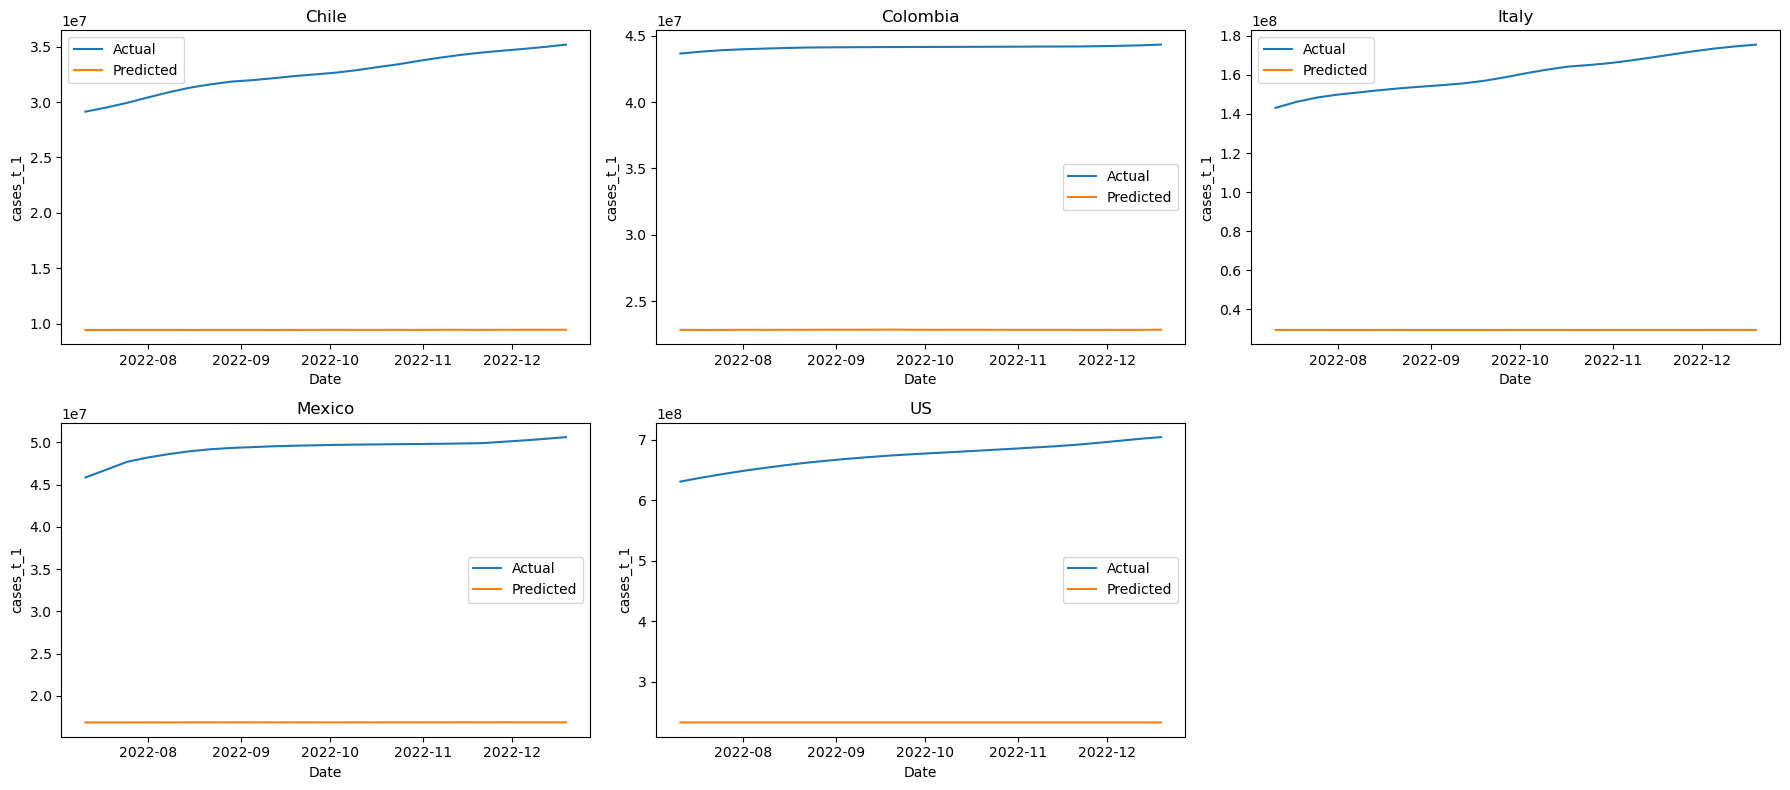

In [33]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid for SVR with an RBF kernel
#    (γ = 1 / (2σ²) in the RBF; tune together with C, ε)
# -------------------------------------------------------------
param_grid = {
    "model__C":       [0.1, 1, 10, 50],
    "model__epsilon": [0.05, 0.1, 0.2],
    "model__gamma":   ["scale", 0.01, 0.1, 1.0]  # 'scale' = 1 / (n_features * X.var)
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])
         .select_dtypes(include='number'))

    # ---- 2.3  Time‑series split: last fold is hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Pipeline: StandardScaler → SVR
    inner_cv = TimeSeriesSplit(n_splits=3)
    svr_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model",  SVR(kernel="linear"))
        ]
    )

    grid = GridSearchCV(
        estimator   = svr_pipe,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)

    best_svr    = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [34]:
fitted_df.to_csv('../results/SVM_covid.csv', index = True)

The models dont capture the trend, even by including the laged cases (cumulative) as a regressor